# Salamander Disease Model — Design v7

## Model Structure

### Strata
- **Offspring strata:** S (susceptible), I (infected) — no movement between sites
- **Adult strata:** R_a (cleared), R_c (chronic carrier) — movement between sites in pre-season window only (custom MovementClause, pending)

### Transmission Pathways
1. **S -> I offspring** (fast, density-dependent) — within-pond larval epidemic driven by `beta` (temperature-scaled Gaussian peaked at 22 degrees C).
2. **R_a -> R_c adults** (slow, active season only) — horizontal adult-to-adult transmission via `SeasonalAdultBeta`. Zero outside active season to prevent winter bleed.
3. **R_c -> S offspring** (environmental, cross-strata) — R_c adults contaminate pond water/sediment. Governed by `beta_env` in `meta_edges`.
4. **R_a -> R_c driven by I offspring** (cross-strata force-of-infection) — infected larvae in pond water expose adults, pushing R_a into chronic carrier state. Rate `beta_force * R_a * I / N_adult` in `meta_edges`.

### Temperature-Dependent Disease Mortality (new in v7)
- Applied to **infected offspring (I) only** — R_c adults are excluded (they have survived past this curve and are now sublethally infected)
- Asymmetric Gaussian peaked at 22 degrees C: sigma_cold=4.0 (steep), sigma_warm=8.0 (gentle — survival improves at 26+ degrees C)
- Reflects empirical ATV findings: peak mortality 18-22 degrees C, moderate at 10 degrees C, meaningful survival at 26 degrees C+
- Returns 0 outside the active season

### Parameter Starting Points (v7)
- beta_max = 0.000187 (literature-derived, temperature-scaled Gaussian)
- beta_adult = 0.001 (active season only via SeasonalAdultBeta)
- beta_env = 0.05 (flat scalar, R_c adults -> S offspring)
- beta_force = 0.01 (I offspring -> R_a adult forcing, cross-strata)
- mortality_max = 1 / 365 (peak daily disease mortality at 22 degrees C, I offspring only)
- p_chronic = 0.4, p_disease_death = 0.20

### Births
- Proportional to total adult population (R_a + R_c)
- p_vert = 0 (no evidence for vertical transmission)
- Birth pulse: days 135-142

### Deaths
- Baseline: SeasonalDeaths — winter 1/365, summer 1/(365*3), all compartments
- Additional: TempDependentMortality — asymmetric Gaussian, I offspring only, active season only

### Seasonality
- Active season: day 135 (May 15) to day 258 (September 15)
- Pre-season movement window: day 105-135 (custom MovementClause, pending)
- Maturation pulse: days 257-259

### Movement
- mm.No() placeholder for adults — custom SeasonalAdultMovement (MovementClause subclass) is the next major engineering task

## Notes
larger "square" grid, sim temperature regimes, sim different phi values (how far they can travel), maybe increase larvae birth
multi-year sims - loop grab population variable per population


In [1]:
# =====================
# Imports and SSL Setup
# =====================

import certifi
import os
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["SSL_CERT_FILE"] = certifi.where()

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import platformdirs
from epymorph.kit import *  # noqa
from pathlib import Path
from sympy import Max
from datetime import date
from epymorph.adrio import us_tiger, prism as prism_adrio

from CustomMovement import CustomCentroids
from epymorph.util import pairwise_haversine

In [2]:
# ==========================================
# Load Temperature and Precipitation (PRISM)
# ==========================================
# Epymorph handles caching internally — data is only downloaded once.
# estimate_data() will report whether data comes from cache or a fresh download.

coconino_scope = CountyScope.in_counties(["04005"], year=2020)
temp_time_frame = TimeFrame.range(date(2020, 1, 1), date(2020, 12, 31))

mean_temp_adrio = prism_adrio.Temperature("Mean")
precip_adrio = prism_adrio.Precipitation()

with sim_messaging(live=False):
    temperature_data = mean_temp_adrio.with_context(
        scope=coconino_scope,
        time_frame=temp_time_frame,
        params={"centroid": us_tiger.GeometricCentroid()},
    ).evaluate()

    precip_data = precip_adrio.with_context(
        scope=coconino_scope,
        time_frame=temp_time_frame,
        params={"centroid": us_tiger.GeometricCentroid()},
    ).evaluate()

daily_temps = temperature_data[:, 0]
daily_precip = precip_data[:, 0]

print(f"Temperature — Min: {daily_temps.min():.1f}°C, Max: {daily_temps.max():.1f}°C")
print(f"Precipitation — Min: {daily_precip.min():.1f}mm, Max: {daily_precip.max():.1f}mm")

Temperature — Min: -8.6°C, Max: 24.9°C
Precipitation — Min: 0.0mm, Max: 48.3mm


In [3]:
# =====================
# Load Custom Pond Data
# =====================

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    # works in Jupyter notebooks — resolves to wherever the notebook file is
    current_dir = Path().resolve().parent

test_data_path = current_dir / "data" / "basicTestData.csv"

df = pd.read_csv(test_data_path)

site_ids = df["site_id"].astype(str).tolist()
scope = CustomScope(site_ids)

total_pop = np.array(df["n_salamanders"].tolist(), dtype=int)

seed_location_index = 2
seed_size = int(df.loc[seed_location_index, "initial_infected"])

# One year timeframe
time = TimeFrame.of("2020-01-01", duration_days=365)

adult_frac = 0.40
adult_pop = np.floor(total_pop * adult_frac).astype(int)
offspring_pop = (total_pop - adult_pop).astype(int)

In [4]:
# ========================
# Compute Distance Matrix
# ========================
coords = (
    df["lon"].to_numpy(dtype=float),
    df["lat"].to_numpy(dtype=float),
)
distance_km = pairwise_haversine(coords, units="kilometers")

In [5]:
# =========================
# Variables for Seasonality
# =========================

season_start = 135  # May 15
season_end = 258    # September 15

In [6]:
# ================================
# Offspring IPM: S, I + deaths
# ================================

class OffspringSI(CompartmentModel):
    compartments = [
        compartment("S", "susceptible offspring"),
        compartment("I", "infected offspring"),
    ]

    requirements = [
        AttributeDef("beta", type=float, shape=Shapes.TxN,
                     comment="offspring transmission rate (temperature-driven Gaussian, peaked at 22C)"),
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="offspring natural mortality rate"),
        AttributeDef("temp_disease_death_rate", type=float, shape=Shapes.TxN,
                     comment="temperature-dependent disease mortality (asymmetric Gaussian, peak 22C, I offspring only)"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        S, I = symbols.all_compartments
        beta, mu, temp_disease_death_rate = symbols.all_requirements

        N = Max(1, S + I)

        return [
            edge(S, I, rate=beta * S * I / N),
            edge(S, DEATH, rate=mu * S),
            edge(I, DEATH, rate=mu * I),
            # Temperature-dependent disease mortality (replaces flat rate)
            edge(I, DEATH, rate=temp_disease_death_rate * I),
        ]


In [7]:
# ================================================
# Adult IPM: R_a (cleared), R_c (chronic carrier)
# ================================================
# R_a → R_c: slow horizontal adult-to-adult transmission at rate beta_adult.
# Adults carry ATV sublethally (sublethal = reservoir, not casualty).
# At beta_adult = 0.001, R_c ideally settles near ~40% of total adults at steady state.

class AdultRaRc(CompartmentModel):
    compartments = [
        compartment("R_a", "cleared adult salamanders"),
        compartment("R_c", "chronic carrier adult salamanders"),
    ]

    requirements = [
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="adult natural mortality rate"),
        AttributeDef("beta_adult", type=float, shape=Shapes.TxN,
                     comment="adult-to-adult horizontal transmission rate (slow, sublethal); ~0.001"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        R_a, R_c = symbols.all_compartments
        mu, beta_adult = symbols.all_requirements

        N_adult = Max(1, R_a + R_c)

        return [
            # Horizontal adult-to-adult transmission: R_a → R_c (slow, density-dependent)
            edge(R_a, R_c, rate=beta_adult * R_a * R_c / N_adult),

            # Natural deaths from each compartment
            edge(R_a, DEATH, rate=mu * R_a),
            edge(R_c, DEATH, rate=mu * R_c),
        ]


In [8]:
# ============================
# Multi-Strata Model Builder
# ============================

class SIR_v7(MultiStrataRUMEBuilder):
    def __init__(self):
        self.strata = [
            GPM(
                name="offspring",
                ipm=OffspringSI(),
                mm=mm.No(),  # offspring cannot move between sites
                init=init.NoInfection(),
            ),
            GPM(
                name="adult",
                ipm=AdultRaRc(),
                # mm.No() used as placeholder — mm.Flat() is WRONG here (no seasonal gating,
                # produces constant daily churn). Custom SeasonalAdultMovement is the fix.
                mm=CustomCentroids(),
                init=init.SingleLocation(
                    initial_compartment="R_a",
                    infection_compartment="R_c",
                    location=seed_location_index,
                    seed_size=seed_size,
                ),
            ),
        ]

        self.meta_requirements = [
            AttributeDef("mature_rate", type=float, shape=Shapes.TxN,
                         comment="end of season maturation rate"),
            AttributeDef("birth_rate", type=float, shape=Shapes.TxN,
                         comment="births per adult per day"),
            AttributeDef("p_chronic", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring become chronic carriers on maturation"),
            AttributeDef("p_disease_death", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring die from disease on maturation"),
            AttributeDef("beta_env", type=float, shape=Shapes.TxN,
                         comment="environmental transmission: R_c adults contaminate pond, infecting S offspring (cross-strata)"),
            AttributeDef("beta_force", type=float, shape=Shapes.TxN,
                         comment="force-of-infection from I offspring onto R_a adults, driving R_a->R_c (cross-strata)"),
        ]

    def meta_edges(self, symbols: MultiStrataModelSymbols) -> list[TransitionDef]:
        S, I = symbols.strata_compartments("offspring")
        R_a, R_c = symbols.strata_compartments("adult")

        mature_rate, birth_rate, p_chronic, p_disease_death, beta_env, beta_force = symbols.all_meta_requirements

        N_offspring = Max(1, S + I)
        N_adult = Max(1, R_a + R_c)

        return [
            # End of season: susceptible offspring mature to cleared adults
            edge(S, R_a, rate=mature_rate * S),

            # End of season: infected offspring fork into three fates
            fork(
                edge(I, DEATH, rate=p_disease_death * mature_rate * I),
                edge(I, R_c, rate=p_chronic * mature_rate * I),
                edge(I, R_a, rate=(1 - p_chronic) * mature_rate * I),
            ),

            # Births: all adults produce susceptible offspring (p_vert = 0 per literature)
            edge(BIRTH, S, rate=birth_rate * (R_a + R_c)),

            # Environmental transmission (cross-strata): R_c adults contaminate pond water,
            # infecting S offspring. Must live in meta_edges because it crosses strata.
            edge(S, I, rate=beta_env * S * R_c / N_offspring),

            # Cross-strata force-of-infection: infected offspring drive R_a adults into R_c.
            # Models adult exposure to virus shed by larvae into pond water during breeding season.
            edge(R_a, R_c, rate=beta_force * R_a * I / N_adult),
        ]


In [9]:
# ================================================
# Seasonal Beta (Temperature-Driven Transmission)
# ================================================
# Beta follows a Gaussian peaked at 22°C, the optimal temperature for ATV transmission.
# Outside the active season, beta = 0.
# sigma controls how steeply beta drops away from the optimal temperature.

class SeasonalBeta(ParamFunctionTimeAndNode):
    def __init__(self, temps: np.ndarray):
        self.temps = temps

    def evaluate1(self, day: int, node_index: int) -> float:
        beta_max = 0.000187
        beta_off = 0.0

        t_mod = day % 365

        if not (season_start <= t_mod <= season_end):
            return beta_off

        temp = self.temps[t_mod]

        optimal_temp = 22.0
        sigma = 5.0

        beta_scaled = beta_max * np.exp(-((temp - optimal_temp) ** 2) / (2 * sigma ** 2))

        return beta_scaled

In [10]:
# =================================================
# Seasonal Adult Beta (Adult-to-Adult Transmission)
# =================================================
# Gates adult-to-adult horizontal transmission to the active season only (days 135-258).
# A flat beta_adult bleeds R_a->R_c continuously through ~200 winter days even at low rates.
# Returning 0.0 outside the active season stops this entirely.

class SeasonalAdultBeta(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        beta_adult_max = 0.001  # tune: lower = fewer R_a->R_c conversions per season
        t_mod = day % 365
        if season_start <= t_mod <= season_end:
            return beta_adult_max
        return 0.0


In [11]:
# ===============
# Seasonal Births
# ===============
# Birth pulse occurs during the first 7 days of the active season.

class SeasonalBirths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        birth_season = 1 / 20
        birth_off = 0.0

        t_mod = day % 365

        if season_start <= t_mod <= season_start + 7:
            return birth_season
        else:
            return birth_off

In [12]:
# ==============================================
# Temperature-Dependent Disease Mortality (v7)
# ==============================================
# Asymmetric Gaussian peaked at 22C — steeper on the cold side (sigma_cold=4),
# gentler on the warm side (sigma_warm=8). Reflects empirical ATV findings:
#   - Peak mortality at 18-22C
#   - Moderate mortality at 10C
#   - Meaningful survival at 26C+ as immune response partially compensates
#
# Applied to infected offspring (I) ONLY as an additional disease-mortality term
# on top of baseline SeasonalDeaths. R_c adults are excluded — they are assumed
# to have already survived this curve and are now chronically infected without symptoms.
# Returns 0 outside the active season.

class TempDependentMortality(ParamFunctionTimeAndNode):
    def __init__(self, temps: np.ndarray):
        self.temps = temps

    def evaluate1(self, day: int, node_index: int) -> float:
        t_mod = day % 365
        if not (season_start <= t_mod <= season_end):
            return 0.0

        temp = self.temps[t_mod]
        peak_temp = 22.0
        sigma_cold = 4.0   # steeper drop toward cold temperatures
        sigma_warm = 8.0   # gentler drop toward warm (survival improves at 26C+)
        mortality_max = 1/365  # tune: max additional daily disease mortality at peak temp

        if temp <= peak_temp:
            return mortality_max * np.exp(-((temp - peak_temp) ** 2) / (2 * sigma_cold ** 2))
        else:
            return mortality_max * np.exp(-((temp - peak_temp) ** 2) / (2 * sigma_warm ** 2))


In [13]:
# ===============
# Seasonal Deaths
# ===============
# Higher mortality in winter (adults only); lower mortality in summer (adults and juveniles).

class SeasonalDeaths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        winter = 1 / 365
        summer = 1 / (365 * 3)

        t_mod = day % 365

        if t_mod >= season_end or t_mod < season_start:
            return winter
        else:
            return summer

In [14]:
# ===================
# Seasonal Maturation
# ===================
# All offspring mature to adults over a 3-day window at the end of the season (day 257-259).

class SeasonalMaturation(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        move_all = 1.0
        season = 0.0

        t_mod = day % 365

        if t_mod >= season_end - 1 and t_mod <= season_end + 1:
            return move_all
        else:
            return season

In [15]:
# ================
# Build the RUME
# ================

rume = SIR_v7().build(
    scope=scope,
    time_frame=time,
    params={
        # Offspring IPM params
        "gpm:offspring::ipm::beta": SeasonalBeta(daily_temps),
        "gpm:offspring::ipm::death_rate": SeasonalDeaths(),
        "gpm:offspring::ipm::temp_disease_death_rate": TempDependentMortality(daily_temps),

        # Adult IPM params
        "gpm:adult::ipm::death_rate": SeasonalDeaths(),
        "gpm:adult::ipm::beta_adult": SeasonalAdultBeta(),

        # Meta params
        "meta::ipm::mature_rate": SeasonalMaturation(),
        "meta::ipm::birth_rate": SeasonalBirths(),
        "meta::ipm::p_chronic": 0.4,
        "meta::ipm::p_disease_death": 0.20,
        "meta::ipm::beta_env": 0.05,
        "meta::ipm::beta_force": 0.01,

        # Populations per strata
        "gpm:offspring::init::population": 0,
        "gpm:adult::init::population": adult_pop.tolist(),

        # Adult movement params
        "gpm:adult::mm::population": adult_pop.tolist(),
        "gpm:adult::mm::centroid": site_ids,
        "gpm:adult::mm::phi": 0.5,
        "gpm:adult::mm::commuter-proportion": 1.0,
    },
)


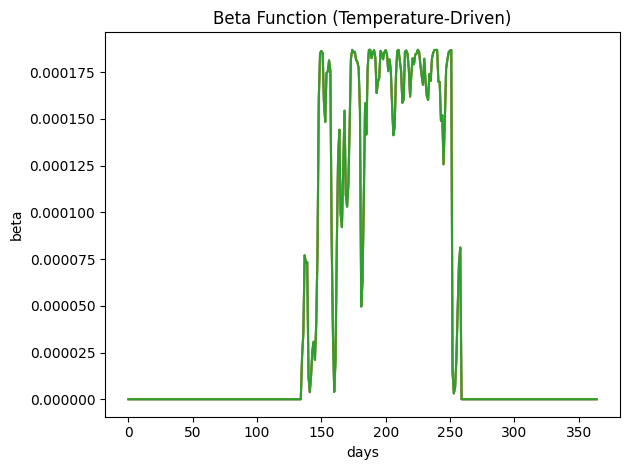

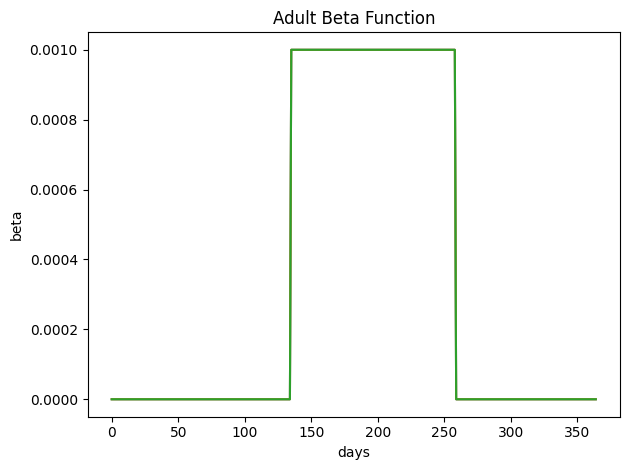

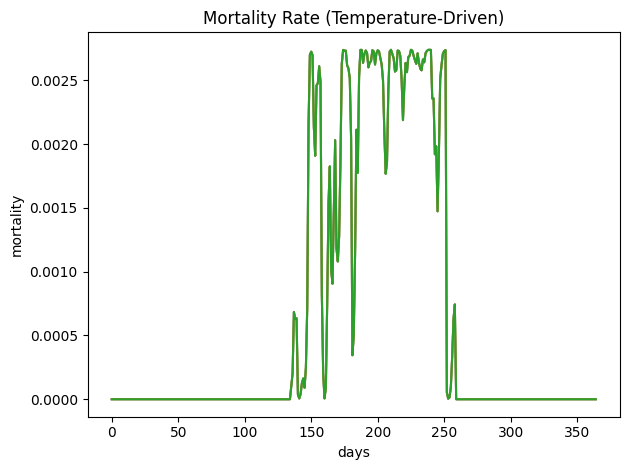

In [16]:
# ==============================
# View Parameters and Model Diagram
# ==============================

# Beta rate over time
beta_values = (
    SeasonalBeta(daily_temps)
    .with_context(
        scope=rume.scope,
        time_frame=rume.time_frame,
    )
    .evaluate()
)

fig, ax = plt.subplots()
ax.plot(beta_values)
ax.set(title="Beta Function (Temperature-Driven)", ylabel="beta", xlabel="days")
fig.tight_layout()
plt.show()

# Adult-to-adult beta over time
beta_adult_values = (
    SeasonalAdultBeta()
    .with_context(
        scope=rume.scope,
        time_frame=rume.time_frame,
    )
    .evaluate()
)

fig, ax = plt.subplots()
ax.plot(beta_adult_values)
ax.set(title="Adult Beta Function", ylabel="beta", xlabel="days")
fig.tight_layout()
plt.show()

# Mortality rate over time
mortality_values = (
    TempDependentMortality(daily_temps)
    .with_context(
        scope=rume.scope,
        time_frame=rume.time_frame,
    )
    .evaluate()
)

fig, ax = plt.subplots()
ax.plot(mortality_values)
ax.set(title="Mortality Rate (Temperature-Driven)", ylabel="mortality", xlabel="days")
fig.tight_layout()
plt.show()

# build model figure (uncomment to view, takes ~15 seconds to render)
#fig = rume.ipm.diagram()

Distance-based movement kernel (rows = origin, cols = destination):


,Pond_A,Pond_B,Pond_C
Pond_A,0.000,0.000,1.0
Pond_B,0.000,0.000,1.0
Pond_C,0.498,0.502,0.0


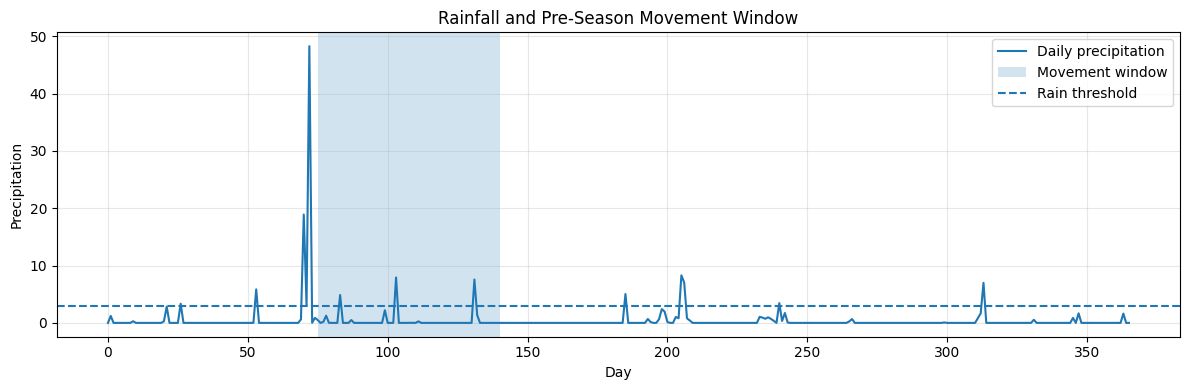

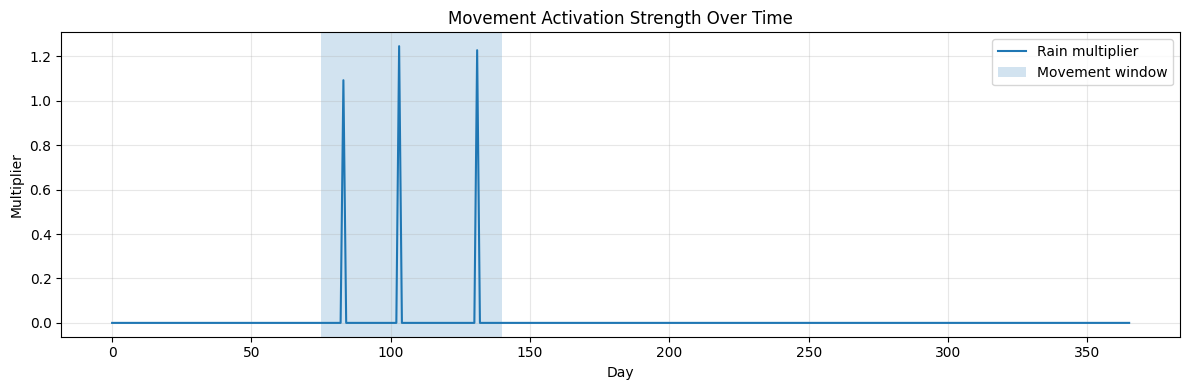

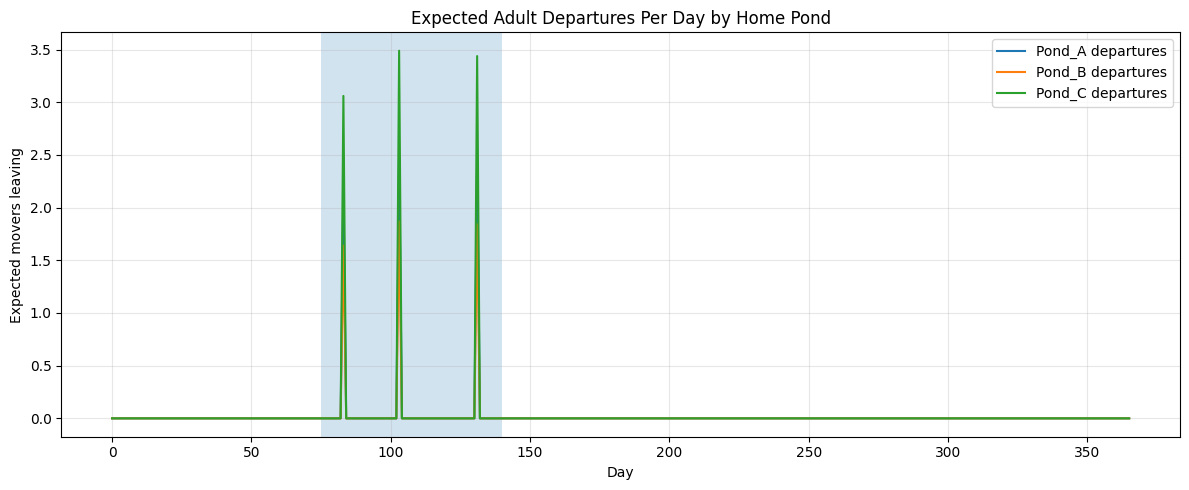

Peak movement day: 103
Rain on peak day: 7.924
Rain multiplier on peak day: 1.246

Expected flow matrix on peak movement day (rows = origin, cols = destination):


,Pond_A,Pond_B,Pond_C
Pond_A,0.000,0.000,2.492
Pond_B,0.000,0.000,1.869
Pond_C,1.739,1.751,0.000


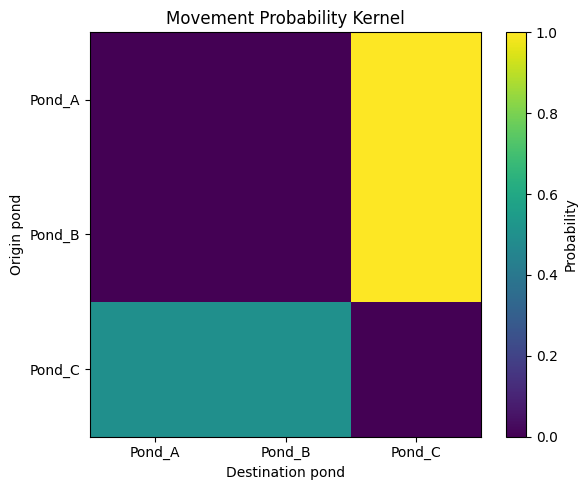

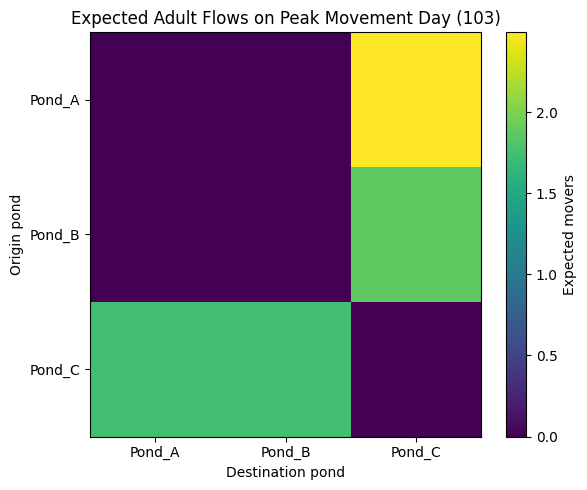

In [17]:
# ==============================
# Movement Diagnostics
# ==============================

# Make sure these match the values you passed into the build params
move_proportion = 0.05
distance_scale_km = 0.25
move_start_day = 75
move_end_day = 140
rain_threshold = 3.0
rain_sensitivity = 0.05

ponds = site_ids

# --- 1) Build the distance-based movement kernel ---
kernel = np.exp(-distance_km / max(distance_scale_km, 1e-9))
np.fill_diagonal(kernel, 0.0)

row_sums = kernel.sum(axis=1, keepdims=True)
zero_rows = (row_sums == 0).ravel()
if np.any(zero_rows):
    kernel[zero_rows, :] = 1.0
    np.fill_diagonal(kernel, 0.0)
    row_sums = kernel.sum(axis=1, keepdims=True)

kernel = kernel / row_sums

print("Distance-based movement kernel (rows = origin, cols = destination):")
kernel_df = pd.DataFrame(kernel, index=ponds, columns=ponds)
display(kernel_df.round(3))

# --- 2) Compute daily rain multiplier during the year ---
rain_multiplier = np.zeros(len(daily_precip), dtype=float)

for day in range(len(daily_precip)):
    if move_start_day <= day <= move_end_day:
        rain_today = daily_precip[day]

        if rain_today < rain_threshold:
            rain_multiplier[day] = 0.0
        else:
            if rain_sensitivity <= 0:
                rain_multiplier[day] = 1.0
            else:
                rain_multiplier[day] = 1.0 + rain_sensitivity * (rain_today - rain_threshold)
    else:
        rain_multiplier[day] = 0.0

# --- 3) Expected movers leaving each pond per day ---
# This mirrors the logic in your movement clause:
# movers_from_origin(day) = adult_pop * move_proportion * rain_multiplier(day)

expected_movers = np.zeros((len(daily_precip), len(ponds)), dtype=float)

for day in range(len(daily_precip)):
    expected_movers[day, :] = adult_pop * move_proportion * rain_multiplier[day]

expected_movers_df = pd.DataFrame(expected_movers, columns=ponds)

# --- 4) Plot rainfall and movement activation ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_precip, label="Daily precipitation")
ax.axvspan(move_start_day, move_end_day, alpha=0.2, label="Movement window")
ax.axhline(rain_threshold, linestyle="--", label="Rain threshold")
ax.set_title("Rainfall and Pre-Season Movement Window")
ax.set_xlabel("Day")
ax.set_ylabel("Precipitation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 5) Plot rain multiplier / activation strength ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rain_multiplier, label="Rain multiplier")
ax.axvspan(move_start_day, move_end_day, alpha=0.2, label="Movement window")
ax.set_title("Movement Activation Strength Over Time")
ax.set_xlabel("Day")
ax.set_ylabel("Multiplier")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 6) Plot expected movers leaving each pond per day ---
fig, ax = plt.subplots(figsize=(12, 5))
for i, pond in enumerate(ponds):
    ax.plot(expected_movers[:, i], label=f"{pond} departures")
ax.axvspan(move_start_day, move_end_day, alpha=0.2)
ax.set_title("Expected Adult Departures Per Day by Home Pond")
ax.set_xlabel("Day")
ax.set_ylabel("Expected movers leaving")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 7) Show expected flow matrix on the most active movement day ---
peak_day = int(np.argmax(rain_multiplier))
peak_multiplier = rain_multiplier[peak_day]

expected_departures_peak = adult_pop * move_proportion * peak_multiplier
expected_flow_peak = expected_departures_peak[:, None] * kernel

flow_peak_df = pd.DataFrame(expected_flow_peak, index=ponds, columns=ponds)

print(f"Peak movement day: {peak_day}")
print(f"Rain on peak day: {daily_precip[peak_day]:.3f}")
print(f"Rain multiplier on peak day: {peak_multiplier:.3f}")
print("\nExpected flow matrix on peak movement day (rows = origin, cols = destination):")
display(flow_peak_df.round(3))

# --- 8) Heatmap of kernel ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(kernel, aspect="auto")
ax.set_xticks(range(len(ponds)))
ax.set_yticks(range(len(ponds)))
ax.set_xticklabels(ponds)
ax.set_yticklabels(ponds)
ax.set_title("Movement Probability Kernel")
ax.set_xlabel("Destination pond")
ax.set_ylabel("Origin pond")
fig.colorbar(im, ax=ax, label="Probability")
plt.tight_layout()
plt.show()

# --- 9) Heatmap of expected flows on peak day ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(expected_flow_peak, aspect="auto")
ax.set_xticks(range(len(ponds)))
ax.set_yticks(range(len(ponds)))
ax.set_xticklabels(ponds)
ax.set_yticklabels(ponds)
ax.set_title(f"Expected Adult Flows on Peak Movement Day ({peak_day})")
ax.set_xlabel("Destination pond")
ax.set_ylabel("Origin pond")
fig.colorbar(im, ax=ax, label="Expected movers")
plt.tight_layout()
plt.show()

In [18]:
# ==================
# Run the Simulation
# ==================

sim = BasicSimulator(rume)

# for reproducibility
rng_seed = 5

with sim_messaging(live=False):
    out = sim.run(rng_factory=default_rng(rng_seed))

df_out = out.dataframe
ponds = out.rume.scope.node_ids

Traceback (most recent call last):
  File "c:\PythonEnvs\EpymorphEnv\Lib\site-packages\IPython\core\interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\andrew\AppData\Local\Temp\ipykernel_13604\1575858855.py", line 11, in <module>
    out = sim.run(rng_factory=default_rng(rng_seed))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\PythonEnvs\EpymorphEnv\Lib\site-packages\epymorph\simulator\basic\basic_simulator.py", line 108, in run
    raise SimValidationError(err) from None
epymorph.error.SimValidationError: RUME attribute requirements were not met. See errors:
- Attribute 'gpm:adult::mm::centroid' (parameter value 'gpm:adult::mm::centroid') is not properly specified: Not a compatible type.


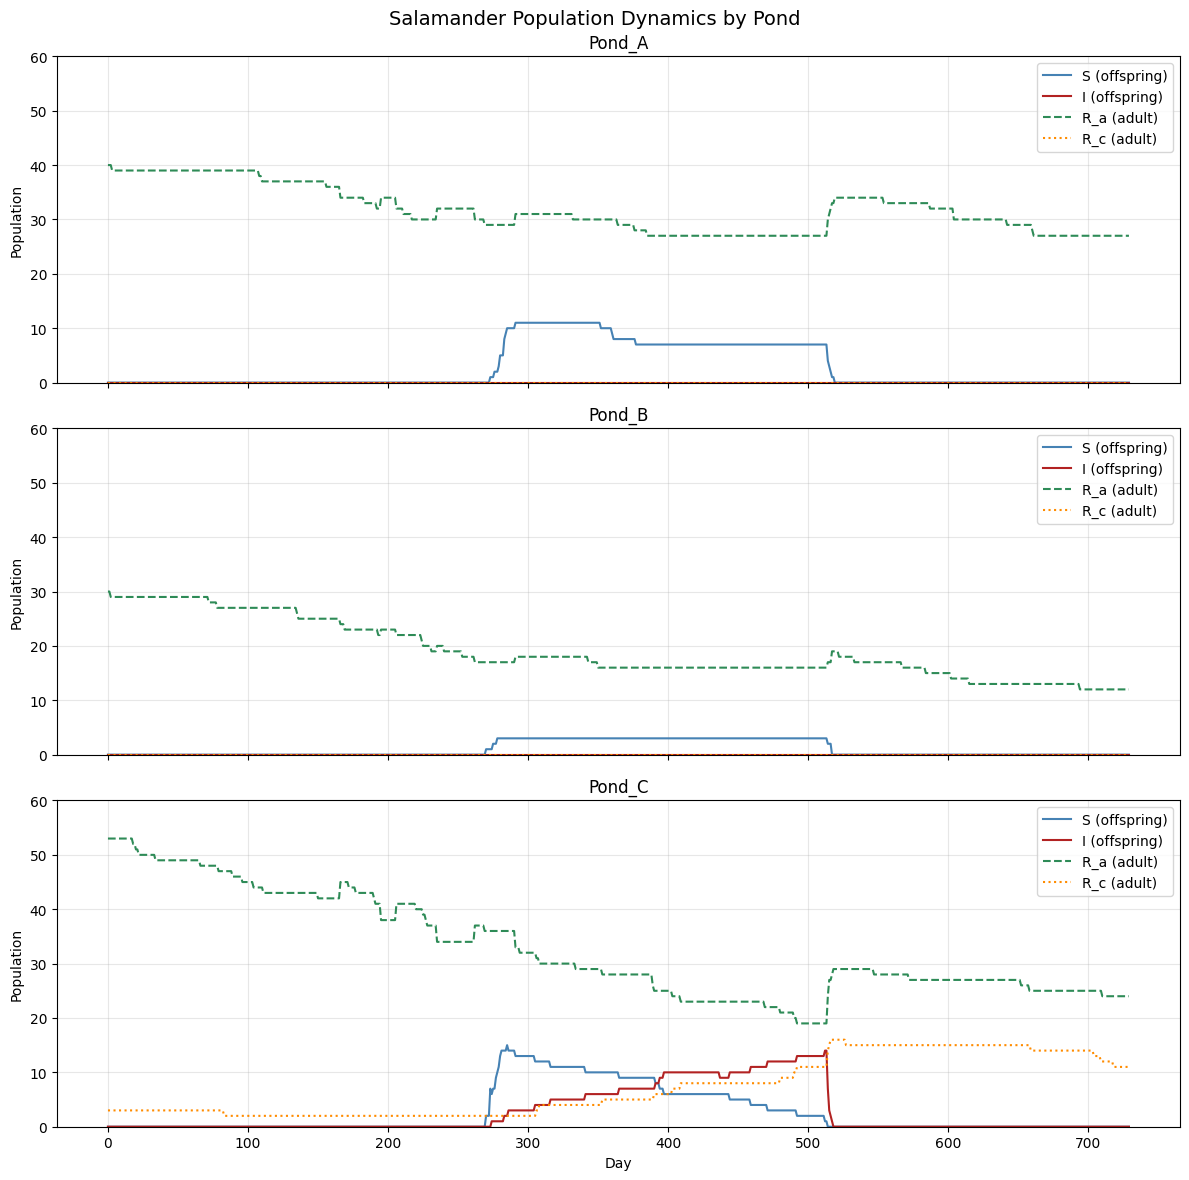

In [ ]:
# ========================
# Plot Simulation Results
# ========================

fig, axes = plt.subplots(len(ponds), 1, figsize=(12, 4 * len(ponds)), sharex=True)

for ax, pond in zip(axes, ponds):
    pond_df = df_out[df_out["node"] == pond]
    ticks = pond_df["tick"].to_numpy()

    ax.plot(ticks, pond_df["S_offspring"].to_numpy(), label="S (offspring)", color="steelblue")
    ax.plot(ticks, pond_df["I_offspring"].to_numpy(), label="I (offspring)", color="firebrick")
    ax.plot(ticks, pond_df["R_a_adult"].to_numpy(), label="R_a (adult)", linestyle="--", color="seagreen")
    ax.plot(ticks, pond_df["R_c_adult"].to_numpy(), label="R_c (adult)", linestyle=":", color="darkorange")

    ax.set_title(f"{pond}")
    ax.set_ylabel("Population")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 60)

axes[-1].set_xlabel("Day")
plt.suptitle("Salamander Population Dynamics by Pond", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ===========
# Diagnostics
# ===========
# Check that maturation works correctly:
# all offspring should transition to adults around day 258.

print("--- Total offspring around maturation (days 254-258) ---")
tot_offspring = df_out.groupby("tick")[["S_offspring", "I_offspring"]].sum()
print(tot_offspring.loc[254:258])

print("\n--- Total adults around maturation (days 254-259) ---")
tot_adults = df_out.groupby("tick")[["R_a_adult", "R_c_adult"]].sum()
print(tot_adults.loc[254:259])

print("\n--- Offspring summary days 250-260 ---")
print(df_out.groupby("tick")[["S_offspring", "I_offspring"]].sum().loc[250:260])

--- Total offspring around maturation (days 254-258) ---
      S_offspring  I_offspring
tick                          
254             0            0
255             0            0
256             0            0
257             0            0
258             0            0

--- Total adults around maturation (days 254-259) ---
      R_a_adult  R_c_adult
tick                      
254          84          2
255          84          2
256          84          2
257          84          2
258          84          2
259          84          2

--- Offspring summary days 250-260 ---
      S_offspring  I_offspring
tick                          
250             0            0
251             0            0
252             0            0
253             0            0
254             0            0
255             0            0
256             0            0
257             0            0
258             0            0
259             0            0
260             0            0


: 

: 

: 

: 

...

: 

: 

: 

: 

: 